#### PCA : 주성분 분석
PCA(Principle Componet Analysis) - 주성분 분석

여러개의 변수(특성 feature) 대표할 수 있는 주성분 이라는 새로운 변수를 만든다.
여러개의 3D 이미지(공간)를 잘 설명할 수 있는 2D 이미지(그림자)를 찾는다. 

PCA는 많은 정보(여러 특성)를 압축해서, 가장 중요한 방향(주성분) 몇 개만 남겨도 원래 데이터(모양)를 거의 잘 표현하게 만드는 방법이야.
쉽게 말하면 **“3D 물체를 2D 그림자로 줄여서도 모양이 잘 보이게 하는 기술”**이야.

1단계: 데이터 표준화 (Standardization)
각 변수의 평균을 0, 분산을 1로 만들어서 모든 데이터가 동일한 스케일로 맞춤
ex. 키(3자리)와 몸무게(2자리)

In [ ]:
# 2단계 : 공분산 행렬 계산 (Covariance Matrix)
# 공분산 : 두 변수가 함께 어떻게 변하는지는 나타내는 값
# 양수 : 한 변수가 증가할 때 같이 증가
# 음수 : 한 변수가 증가할 때 반대로 감소
# 공분산 행렬 : 모든 변수 쌍들의 공분산을 행렬로 정리한 것 --> 이 행렬을 통해서 데이터가 어떤 방향으로 퍼져있는지 알 수 있음

In [ ]:
# 3단계 : 고유값과 고유벡터를 계산
# 2단계의 공분산 행렬을 이용해서 고유값과 고유벡터를 찾는다
# 고유값 벡터 : 데이터가 어떤 방향으로 가장 크게 분산(퍼져있는 정도)되어 있는지를 나타내는 방향 벡터. 이 방향이 새로운 축. 즉, 주성분
# 고유값 : 해당 고유벡터 방향으로 데이터가 얼마나 많이 퍼져있는지를 나타내는 힘의 크기. 이 값이 크면 그 방향이 데이터를 더 많이 설명한다는 의미

# PCA : 고유값의 크기 순서에 따라서 제1주성분(PC1), 제2주성분(PC2) 등
# PC1은 데이터를 가장 잘 설명하는 축이고, PC2는 PC1과 직각을 이루면서 그 다음으로 데이터를 잘 표현

In [ ]:
# 4단계 : 주성분 결정 및 데이터 변환
# 계산된 고유벡터축에 원래 데이터를 투영(projection)하여 차원을 축소함
# ex. 붓꽃은 4개의 특성을 2개의 주성분(2차원)으로 변환해서 시각화

| 단계           | 핵심 의미                  | 비유                      |
| ------------ | ---------------------- | ----------------------- |
| 1️⃣ 표준화      | 스케일을 맞춘다               | 키·몸무게 단위 맞추기            |
| 2️⃣ 공분산 계산   | 변수들이 함께 변하는 정도를 본다     | “키 크면 몸무게도 늘어나는가?”      |
| 3️⃣ 고유값·고유벡터 | 가장 퍼진 방향(정보가 많은 방향) 찾기 | 빛을 비춰 그림자가 가장 길게 나오는 방향 |
| 4️⃣ 투영       | 그 방향으로 데이터를 새로 그리기     | 그림자(2D)로 표현하기           |


In [ ]:
%conda install pandas scikit-learn matplotlib seaborn numpy

In [ ]:
%conda update -n base -c defaults conda

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 예제데이터 붓꽃
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.data
df['target'] = iris.target

X=df.drop(columns='target')
y=df.target

# 1단계: 표준화 진행
X_scaled = StandardScaler().fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

[0.72962445 0.22850762]


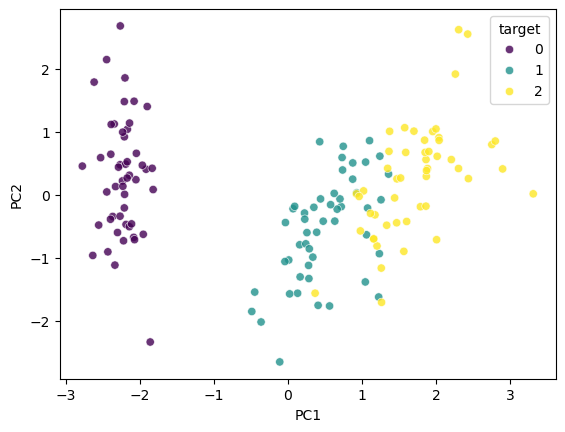

In [20]:
# 2~4 단계 모두 수행 : PCA 수행 및 데이터 변환
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_scaled)
principalComponents [:5] #중간 확인
# 주성분 분석 결과를 DataFrame 으로 변환
pc_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
pc_df['target'] = df.target
pc_df.head() #중간 확인

# 각 주성분이 설명하는 분산의양 (고유값의 중요도)
print (pca.explained_variance_ratio_) #주성분 2개만으로도 전체대비 95.7% 설명할 수 있음??

# 시각화
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='target', alpha=0.8, palette='viridis')  #alpha 투명도
plt.show()

#==> 2개의 데이터(PC1, PC2만으로도 품종을 구분할 수 있다. 


In [ ]:
from sklearn import datasets
from sklearn.ensemble import RandomForestRegressor
# 데이터셋

df = datasets.load_diabetes(as_frame=True)
X=df.data
y=df.target
X.isna().sum()

# 1. 적절한 데이터 전처리
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# 분류모델에서 클래스 stratify= (클래스 비율을 유지 하면서 하는것) 

# 랜덤포레스트 모델 학습
rfr = RandomForestRegressor(max_depth=3)
rfr.fit(X_train, y_train)
# 2. 모델 적용해서 score 를 확인
print (f'non PCA train score : {rfr.score(X_train, y_train)}')
print (f'non PCA test score : {rfr.score(X_test, y_test)}')
# score  : 분류모델 - accuracy(정확도) / 예측모델 - 결정계수
# score 함수 자체가 predict를 계산해줌. 
#####  ==> train score test score 차이가 크니까 과적합. 
# non PCA train score : 0.5851157246207661
# non PCA train score : 0.4751048540311088
# PCA train score : 0.4276534173114207
# PCA train score : 0.3118678692302771

###########################################
# 1. 적절한 데이터 전처리데이터를 가지고 PCA로 주성분을 적당한 개수로 설정해서 데이터를 변환
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42, n_oversamples=20)
X_train_pca=pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
rfr= RandomForestRegressor(max_depth=3)
rfr.fit(X_train_pca,y_train)
# 2. 모델을 적용해서 score를 확인
print (f'PCA train score : {rfr.score(X_train_pca, y_train)}')
print (f'PCA test score : {rfr.score(X_test_pca, y_test)}')


non PCA train score : 0.5822774352735849
non PCA test score : 0.4807117850767798
PCA train score : 0.42753761547949354
PCA test score : 0.30281746093489526


In [ ]:
########## 상기 score 높일 수 있는 방법은?????????????????

In [44]:
# 하이퍼 파라미터 튜닝 : gridsearch
# 학습에 영향을 주는 모든 파라미터


from sklearn import datasets
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


# 데이터셋
df = datasets.load_diabetes(as_frame=True)
X=df.data
y=df.target
X.isna().sum()

# 1. 적절한 데이터 전처리
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rfr = RandomForestRegressor()
param_grid = {
        'max_depth' : [3,5,10,12,15],
        'max_features' : ['sqrt', 'log2'],
        'min_samples_split': [1,2,5,10],
        'min_samples_leaf': [1,3,5,7]
}
gridcv = GridSearchCV(rfr, return_train_score=True, param_grid=param_grid)
gridcv.fit(X_train, y_train)


c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
200 fits failed out of a total of 800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_c

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [ ]:
gridcv.best_score_, gridcv.best_estimator_, gridcv.best_params_

(np.float64(0.44314251058406945),
 RandomForestRegressor(max_depth=12, max_features='sqrt', min_samples_leaf=5),
 {'max_depth': 12,
  'max_features': 'sqrt',
  'min_samples_leaf': 5,
  'min_samples_split': 2})